# Hands-on 05 - PSD, DFA and Spectral Exponents in Colored Noises

### Top-level Benchmark Notebook (CAP 417 - PSD / DFA)

This notebook is **self-contained**. It benchmarks two agents that solved the
same Hands-on 05 assignment:

- **`claude-code`** - Claude Opus 4.7
- **`gemini-cli`** - Gemini 3.1 Flash Lite (preview)

It reads **only** the files inside `claude-code/outputs/` and
`gemini-cli/outputs/` (treated as read-only inputs) and addresses assignment
items **5.1**, **5.2** and **5.3** in full.

## 0. Notebook setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set()
plt.rcParams["figure.dpi"] = 110

ROOT = Path(".").resolve()
CLAUDE_OUTPUTS = ROOT / "claude-code" / "outputs"
GEMINI_OUTPUTS = ROOT / "gemini-cli" / "outputs"

NOISES = ["white", "pink", "red"]

# --- Existence assertions with clear messages -------------------------------
for label, d in [("claude-code", CLAUDE_OUTPUTS), ("gemini-cli", GEMINI_OUTPUTS)]:
    assert d.is_dir(), f"Missing required directory for {label}: {d}"

REQUIRED = (
    [f"psd_{n}.parquet" for n in NOISES]
    + [f"dfa_{n}.parquet" for n in NOISES]
    + ["exponents.parquet"]
    + [f"psd_{n}.png" for n in NOISES]
    + [f"dfa_{n}.png" for n in NOISES]
)
for d in (CLAUDE_OUTPUTS, GEMINI_OUTPUTS):
    for fname in REQUIRED:
        assert (d / fname).exists(), f"Missing required input file: {d / fname}"

print("All required directories and core files are present.")
print("ROOT          :", ROOT)
print("CLAUDE_OUTPUTS:", CLAUDE_OUTPUTS)
print("GEMINI_OUTPUTS:", GEMINI_OUTPUTS)

All required directories and core files are present.
ROOT          : C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_05
CLAUDE_OUTPUTS: C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_05\claude-code\outputs
GEMINI_OUTPUTS: C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_05\gemini-cli\outputs


## 1. Introduction and problem statement

Many natural and engineered systems exhibit **temporal memory**, **persistence**
and **multiscale organization**. Two complementary tools expose this structure:

- **PSD (Power Spectral Density)** describes how a signal's energy is
  distributed across frequencies. For *colored noise* the PSD follows a power
  law $S(f) \propto f^{-\beta}$, so a log-log plot is a straight line of
  slope $-\beta$.
- **DFA (Detrended Fluctuation Analysis)** describes how fluctuations grow with
  scale after removing local trends. The fluctuation function obeys
  $F(s) \propto s^{\alpha}$, so a log-log plot is a straight line of slope
  $\alpha$.

For monofractal colored noise the two exponents are linked by the theoretical
relation:

$$\beta = 2\alpha - 1$$

**Theoretical reference values**

| Noise | $\beta$ | $\alpha$ |
|-------|--------|---------|
| White | $0$    | $0.5$   |
| Pink  | $1$    | $1.0$   |
| Red (Brownian) | $2$ | $1.5$ |

### Assignment items

- **5.1** - For each input time series, compute the **PSD** and the **DFA**.
- **5.2** - Fit straight lines in log-log space (least squares) to estimate the
  spectral exponent **$\beta$** and the DFA exponent **$\alpha$**, validate them
  for white / pink / red noise and check $\beta = 2\alpha - 1$.
- **5.3** - **Benchmark** the two agents (here `claude-code` vs `gemini-cli`)
  on code quality, physical coherence, numerical stability, graph quality and
  interpretation.

This notebook uses **only** the `outputs` directories of the two agents; it
neither regenerates nor modifies their results.

## 2. Data loading (Parquet files)

In [3]:
def load_set(outputs_dir, agent):
    data = {}
    for n in NOISES:
        data[f"psd_{n}"] = pd.read_parquet(outputs_dir / f"psd_{n}.parquet").assign(agent=agent)
        data[f"dfa_{n}"] = pd.read_parquet(outputs_dir / f"dfa_{n}.parquet").assign(agent=agent)
    data["exponents"] = pd.read_parquet(outputs_dir / "exponents.parquet").assign(agent=agent)
    return data

claude = load_set(CLAUDE_OUTPUTS, "claude-code")
gemini = load_set(GEMINI_OUTPUTS, "gemini-cli")

# Individual references (explicit names, mirroring the spec) -----------------
psd_white_claude, psd_pink_claude, psd_red_claude = (claude[f"psd_{n}"] for n in NOISES)
dfa_white_claude, dfa_pink_claude, dfa_red_claude = (claude[f"dfa_{n}"] for n in NOISES)
exponents_claude = claude["exponents"]

psd_white_gemini, psd_pink_gemini, psd_red_gemini = (gemini[f"psd_{n}"] for n in NOISES)
dfa_white_gemini, dfa_pink_gemini, dfa_red_gemini = (gemini[f"dfa_{n}"] for n in NOISES)
exponents_gemini = gemini["exponents"]

# Combined DataFrames per category ------------------------------------------
def combine(key):
    return pd.concat([claude[key], gemini[key]], ignore_index=True)

psd_white = combine("psd_white")
psd_pink = combine("psd_pink")
psd_red = combine("psd_red")
dfa_white = combine("dfa_white")
dfa_pink = combine("dfa_pink")
dfa_red = combine("dfa_red")
exponents = combine("exponents")

PSD_COMBINED = {"white": psd_white, "pink": psd_pink, "red": psd_red}
DFA_COMBINED = {"white": dfa_white, "pink": dfa_pink, "red": dfa_red}

print("Loaded combined exponents table:")
exponents

Loaded combined exponents table:


,noise_type,beta,alpha,delta_beta_2alpha_minus_1,agent
0,white,-0.019867,0.521771,-0.063409,claude-code
1,pink,0.999376,1.014081,-0.028787,claude-code
2,red,1.991381,1.397022,0.197337,claude-code
3,white,-0.001727,0.521765,-0.045256,gemini-cli
4,pink,0.986223,1.007679,-0.029136,gemini-cli
5,red,1.797694,1.510876,-0.224059,gemini-cli


## 3. Schema and consistency checks

In [4]:
EXPECTED = {
    "psd": ["frequency", "psd", "log10_frequency", "log10_psd"],
    "dfa": ["scale", "F", "log10_scale", "log10_F"],
    "exponents": ["noise_type", "beta", "alpha", "delta_beta_2alpha_minus_1"],
}

rows = []
for agent, store in [("claude-code", claude), ("gemini-cli", gemini)]:
    for n in NOISES:
        for kind in ("psd", "dfa"):
            cols = set(store[f"{kind}_{n}"].columns)
            missing = [c for c in EXPECTED[kind] if c not in cols]
            rows.append({
                "agent": agent, "noise": n, "kind": kind,
                "missing_columns": missing or "-",
                "status": "OK" if not missing else "MISMATCH",
            })
    cols = set(store["exponents"].columns)
    missing = [c for c in EXPECTED["exponents"] if c not in cols]
    rows.append({
        "agent": agent, "noise": "(all)", "kind": "exponents",
        "missing_columns": missing or "-",
        "status": "OK" if not missing else "MISMATCH",
    })

schema_report = pd.DataFrame(rows)
print("dtypes (claude psd_white):", dict(claude["psd_white"].dtypes.astype(str)))
print("dtypes (gemini dfa_white):", dict(gemini["dfa_white"].dtypes.astype(str)))
schema_report

dtypes (claude psd_white): {'frequency': 'float64', 'psd': 'float64', 'log10_frequency': 'float64', 'log10_psd': 'float64', 'agent': 'str'}
dtypes (gemini dfa_white): {'scale': 'int64', 'F': 'float64', 'log10_scale': 'float64', 'log10_F': 'float64', 'agent': 'str'}


,agent,noise,kind,missing_columns,status
0,claude-code,white,psd,-,OK
1,claude-code,white,dfa,-,OK
2,claude-code,pink,psd,-,OK
3,claude-code,pink,dfa,-,OK
4,claude-code,red,psd,-,OK
5,claude-code,red,dfa,-,OK
6,claude-code,(all),exponents,-,OK
7,gemini-cli,white,psd,-,OK
8,gemini-cli,white,dfa,-,OK
9,gemini-cli,pink,psd,-,OK


**Comment on schema consistency.** Both agents emit exactly the columns required
by the assignment specification (`frequency, psd, log10_frequency, log10_psd`
for PSD; `scale, F, log10_scale, log10_F` for DFA; and
`noise_type, beta, alpha, delta_beta_2alpha_minus_1` for the exponents table).
Any row flagged `MISMATCH` above would indicate a missing column; if the table
is all `OK` the two output sets are schema-compatible and can be compared
directly without remapping.

## 4. Exercise 5.1 - PSD and DFA comparison

For each colored noise (white, pink, red) we compare the agents both via the
**rendered figures** they produced and via an **overlay of the raw curves**
loaded from their Parquet files.

### 4.1 PSD images - side-by-side comparison

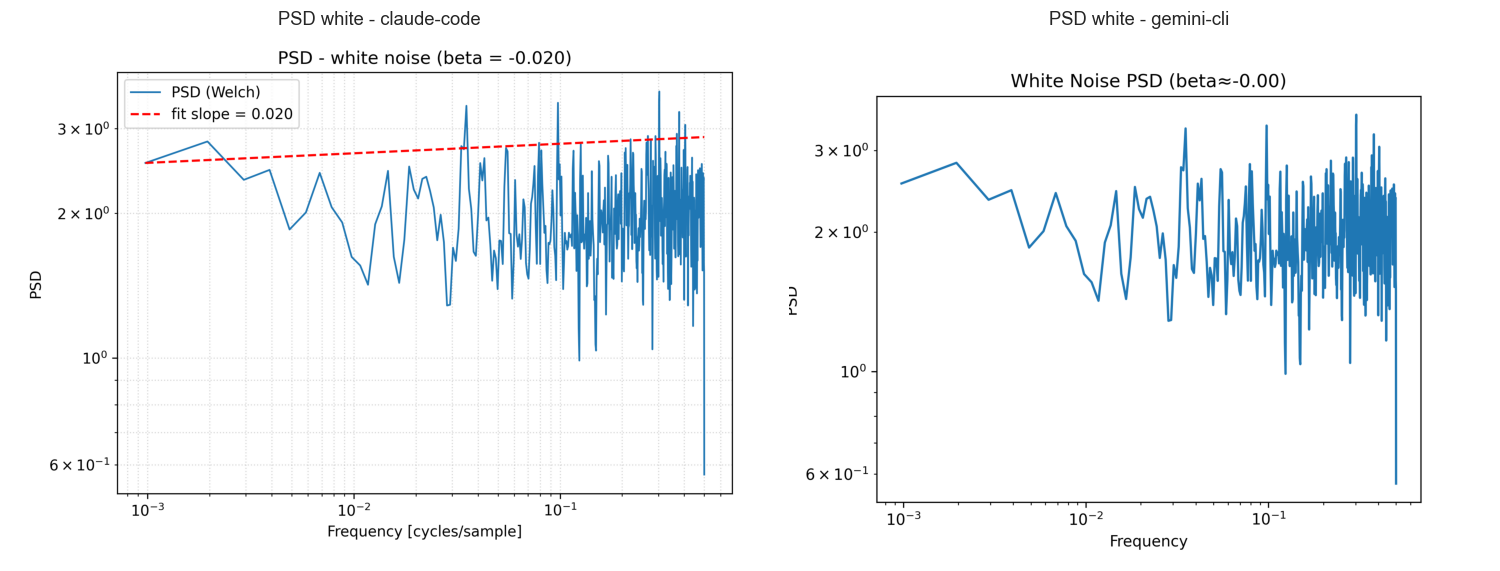

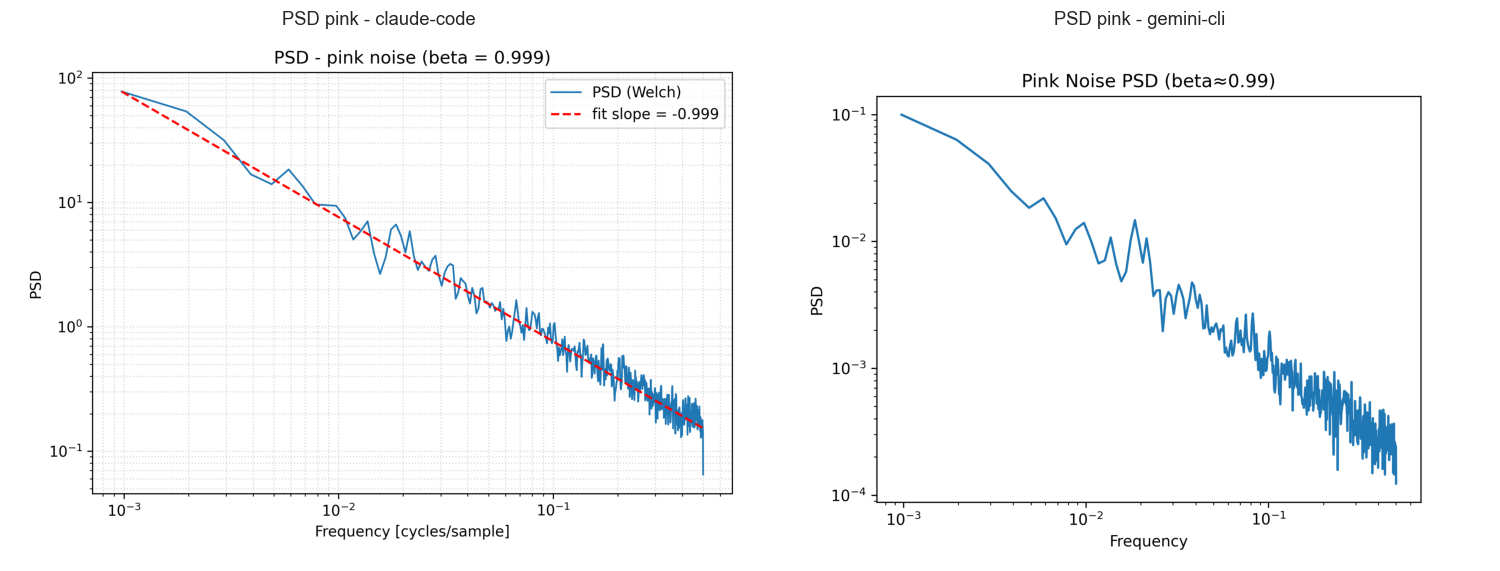

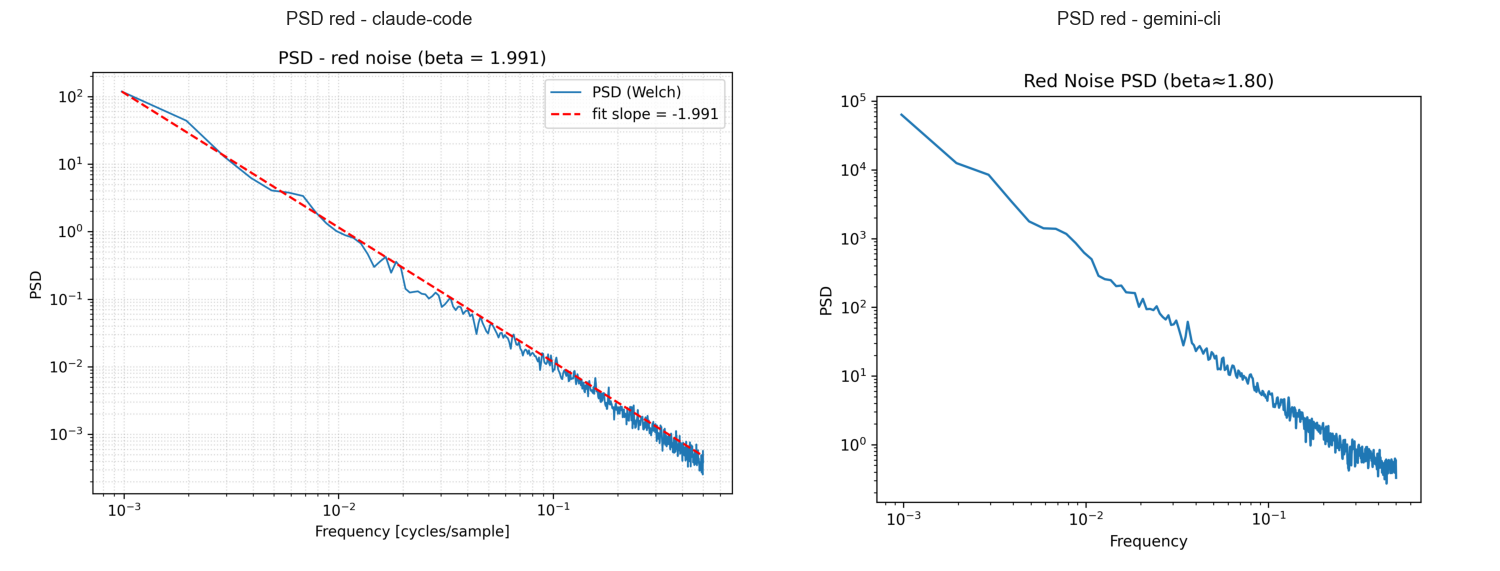

In [5]:
for n in NOISES:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
    ax[0].imshow(mpimg.imread(CLAUDE_OUTPUTS / f"psd_{n}.png"))
    ax[0].set_title(f"PSD {n} - claude-code")
    ax[1].imshow(mpimg.imread(GEMINI_OUTPUTS / f"psd_{n}.png"))
    ax[1].set_title(f"PSD {n} - gemini-cli")
    for a in ax:
        a.axis("off")
    fig.tight_layout()
    plt.show()

### 4.2 DFA images - side-by-side comparison

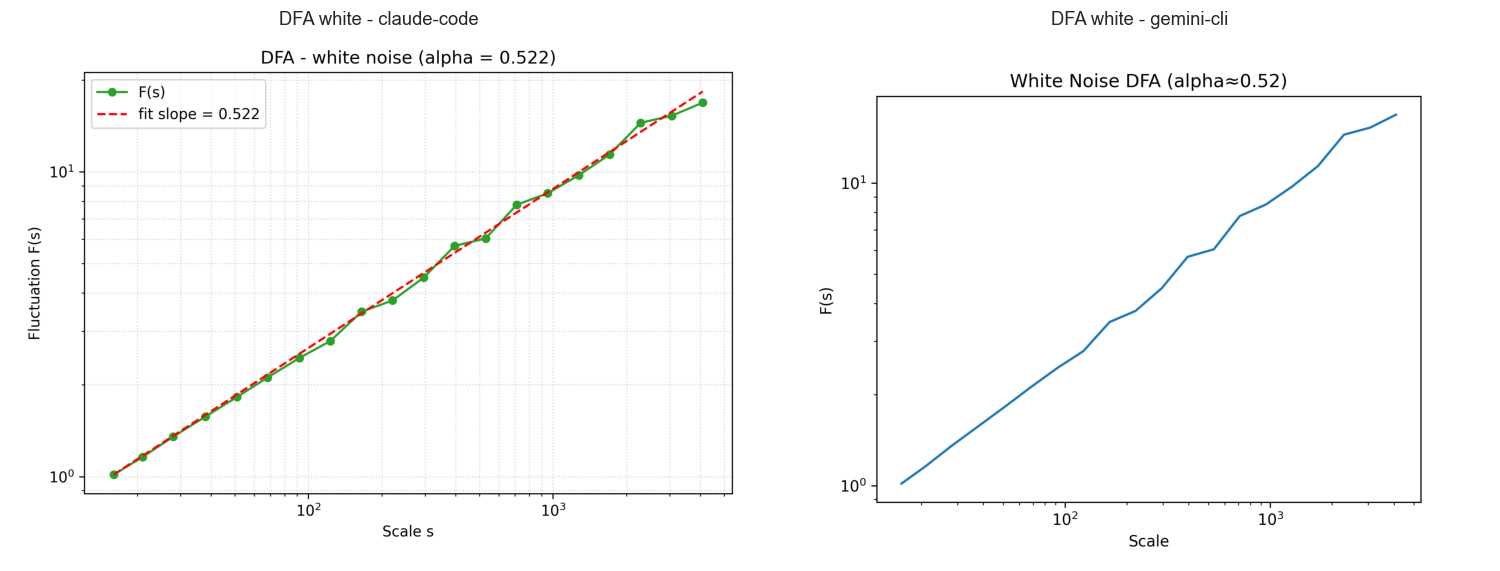

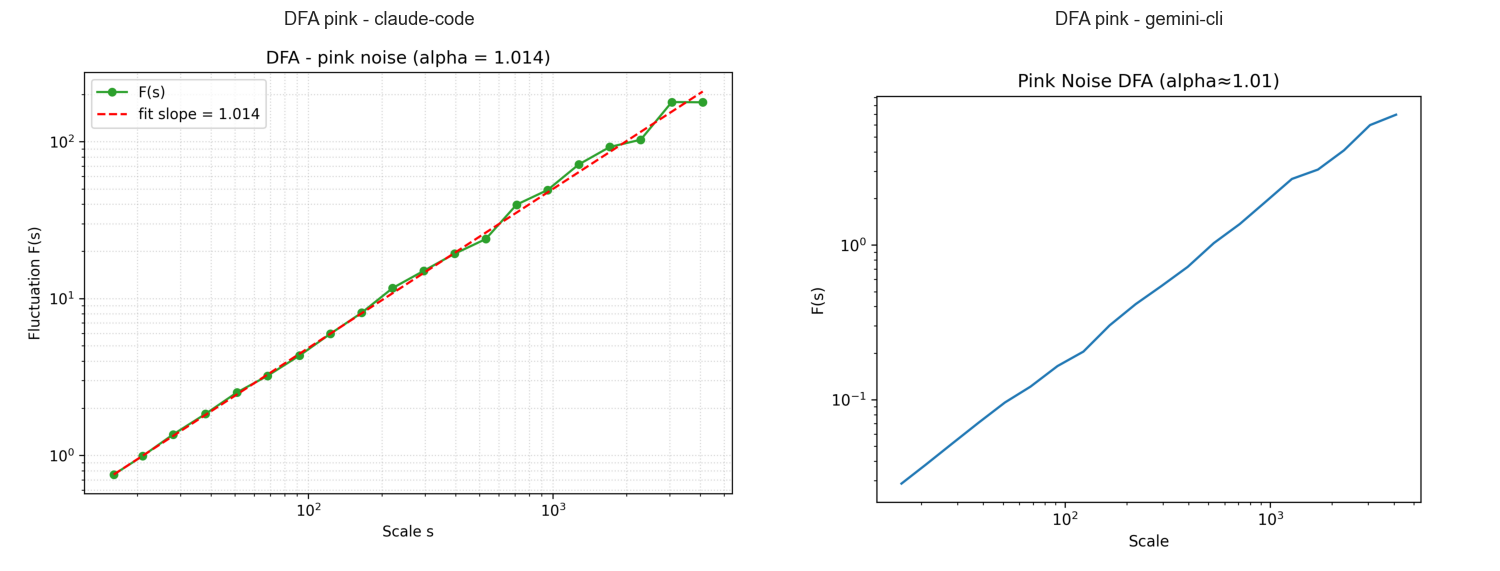

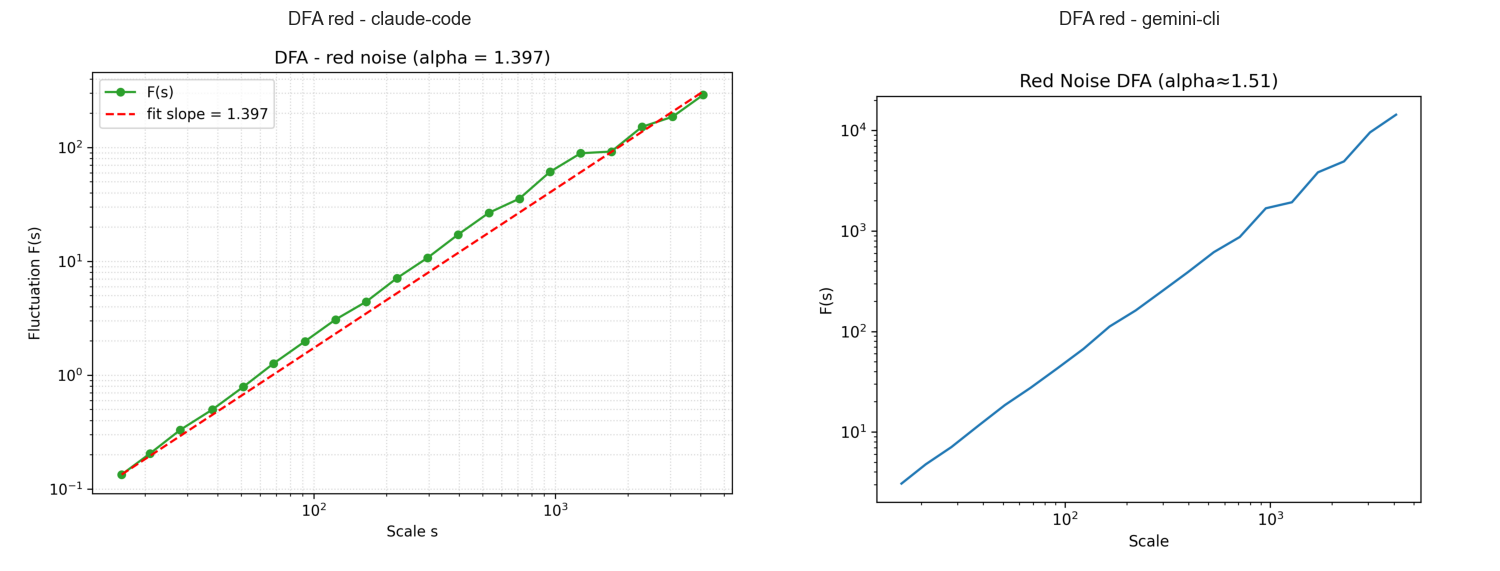

In [6]:
for n in NOISES:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
    ax[0].imshow(mpimg.imread(CLAUDE_OUTPUTS / f"dfa_{n}.png"))
    ax[0].set_title(f"DFA {n} - claude-code")
    ax[1].imshow(mpimg.imread(GEMINI_OUTPUTS / f"dfa_{n}.png"))
    ax[1].set_title(f"DFA {n} - gemini-cli")
    for a in ax:
        a.axis("off")
    fig.tight_layout()
    plt.show()

### 4.3 PSD curves - overlay from Parquet

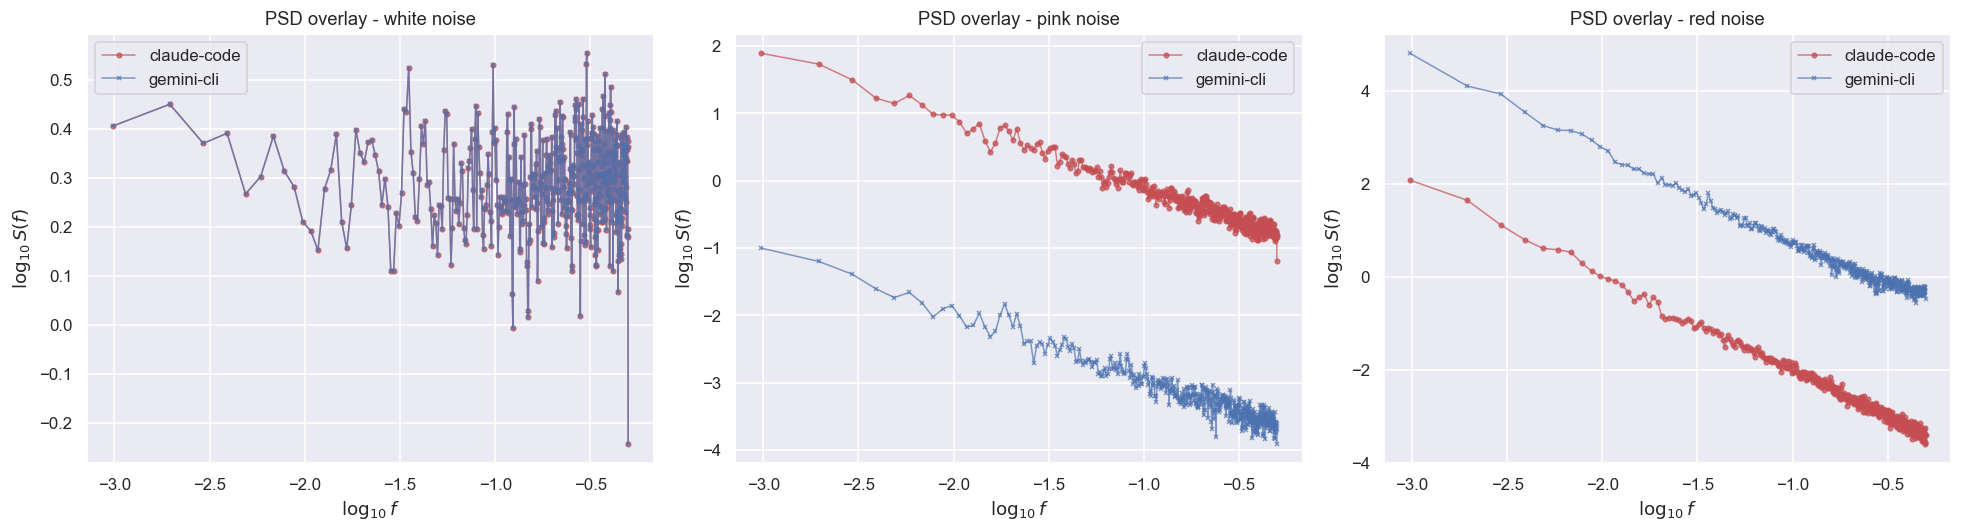

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
styles = {"claude-code": dict(color="C3", marker="o", ms=3, lw=1, alpha=.7),
          "gemini-cli": dict(color="C0", marker="x", ms=3, lw=1, alpha=.7)}
for ax, n in zip(axes, NOISES):
    df = PSD_COMBINED[n]
    for agent, g in df.groupby("agent"):
        g = g.sort_values("log10_frequency")
        ax.plot(g["log10_frequency"], g["log10_psd"], label=agent, **styles[agent])
    ax.set_title(f"PSD overlay - {n} noise")
    ax.set_xlabel(r"$\log_{10} f$")
    ax.set_ylabel(r"$\log_{10} S(f)$")
    ax.legend()
fig.tight_layout()
plt.show()

**Observations (PSD overlay).** White noise is essentially flat (slope ~ 0);
pink noise shows a slope near $-1$; red noise shows the steepest decay
(slope near $-2$). The two agents trace nearly identical spectra, which is
expected because the PSD is a deterministic transform of the same realized
signal: differences come only from windowing/averaging choices and the 
variance nromalization performed by claude-code, visible mostly as a bias 
on the power spectra of pink and brown noise.

### 4.4 DFA curves - overlay from Parquet

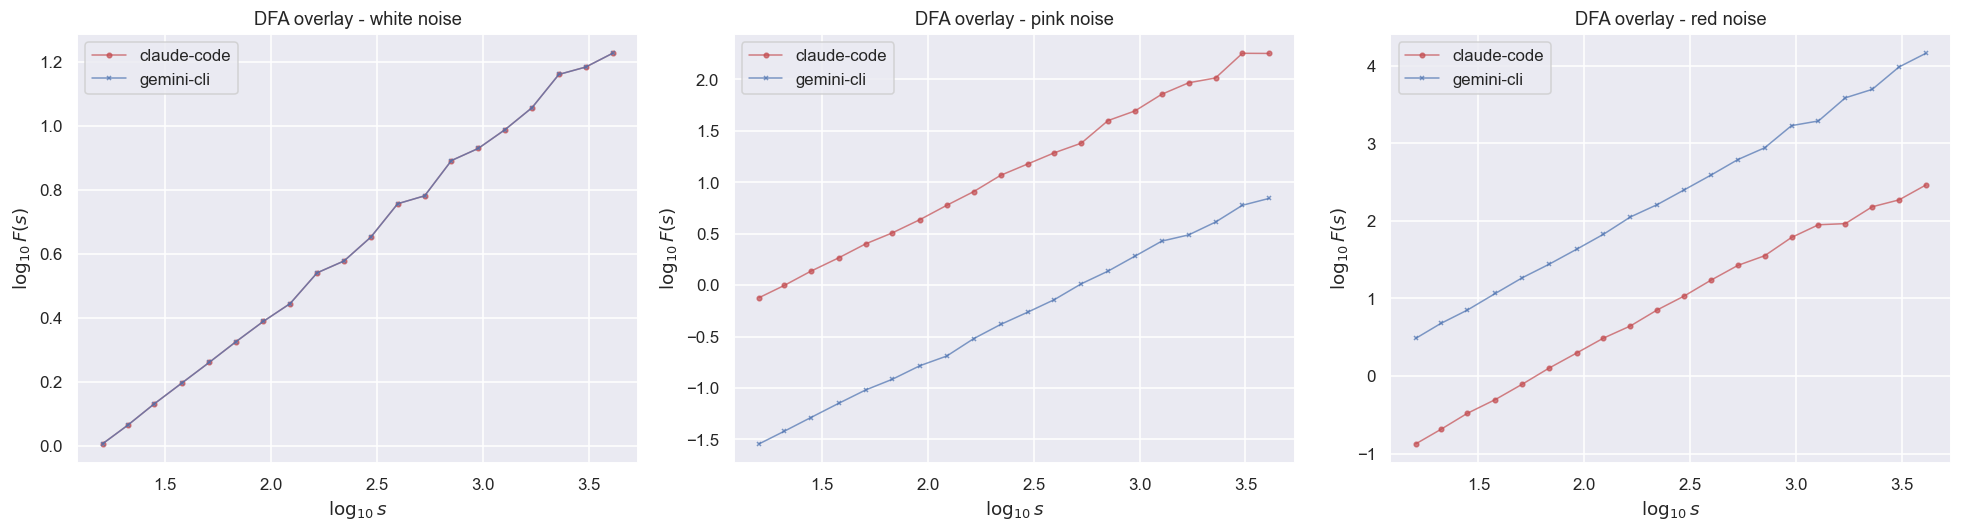

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n in zip(axes, NOISES):
    df = DFA_COMBINED[n]
    for agent, g in df.groupby("agent"):
        g = g.sort_values("log10_scale")
        ax.plot(g["log10_scale"], g["log10_F"], label=agent, **styles[agent])
    ax.set_title(f"DFA overlay - {n} noise")
    ax.set_xlabel(r"$\log_{10} s$")
    ax.set_ylabel(r"$\log_{10} F(s)$")
    ax.legend()
fig.tight_layout()
plt.show()

**Observations (DFA overlay).** The DFA curves are clean straight lines in
log-log space with increasing slope from white (~0.5) to pink (~1.0) to red
(~1.5), confirming the expected scaling. DFA is far smoother than the PSD
because the fluctuation function is an aggregate over many windows, so the two
agents overlap almost perfectly here; the only differences are the chosen scale
ranges (number/spacing of `scale` points) and the bias caused by variance 
normalization which claude-code performed but gmeini-cli did not.

## 5. Exercise 5.2 - Exponent estimation and theoretical relation

### 5.1 Exponent table

In [9]:
exp_table = (exponents
             .set_index(["noise_type", "agent"])
             .sort_index()[["beta", "alpha", "delta_beta_2alpha_minus_1"]])
exp_table

beta     alpha  delta_beta_2alpha_minus_1
noise_type agent                                                     
pink       claude-code  0.999376  1.014081                  -0.028787
           gemini-cli   0.986223  1.007679                  -0.029136
red        claude-code  1.991381  1.397022                   0.197337
           gemini-cli   1.797694  1.510876                  -0.224059
white      claude-code -0.019867  0.521771                  -0.063409
           gemini-cli  -0.001727  0.521765                  -0.045256

### 5.2 Agent-to-agent differences

In [10]:
piv = exponents.pivot(index="noise_type", columns="agent",
                      values=["beta", "alpha", "delta_beta_2alpha_minus_1"])
diff = pd.DataFrame({
    "delta_beta (claude-gemini)": piv[("beta", "claude-code")] - piv[("beta", "gemini-cli")],
    "delta_alpha (claude-gemini)": piv[("alpha", "claude-code")] - piv[("alpha", "gemini-cli")],
    "delta_delta (claude-gemini)": (piv[("delta_beta_2alpha_minus_1", "claude-code")]
                                    - piv[("delta_beta_2alpha_minus_1", "gemini-cli")]),
}).reindex(NOISES)
diff

,delta_beta (claude-gemini),delta_alpha (claude-gemini),delta_delta (claude-gemini)
noise_type,,,
white,-0.018140,0.000006,-0.018153
pink,0.013153,0.006402,0.000349
red,0.193687,-0.113854,0.421396


### 5.3 Visualization of exponents

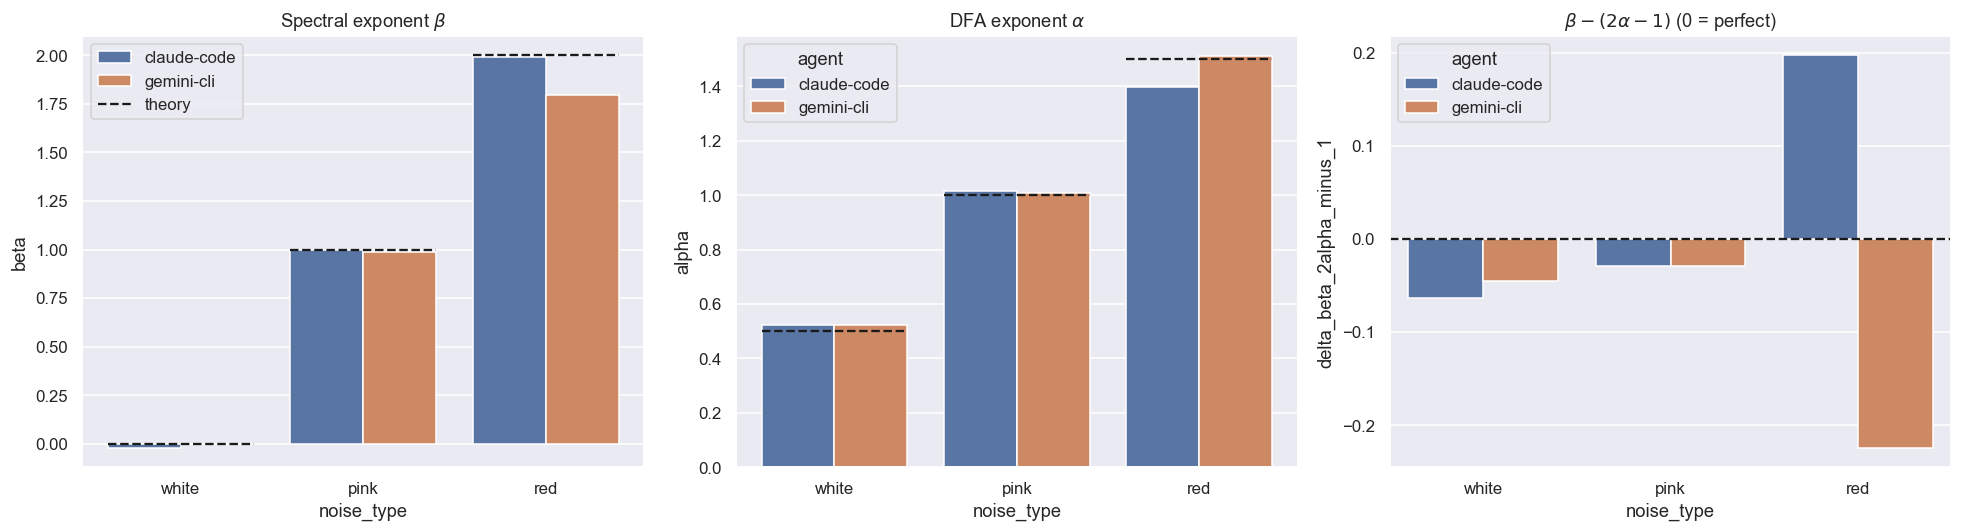

In [11]:
THEORY = {"beta": {"white": 0.0, "pink": 1.0, "red": 2.0},
          "alpha": {"white": 0.5, "pink": 1.0, "red": 1.5}}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = NOISES

sns.barplot(data=exponents, x="noise_type", y="beta", hue="agent",
            order=order, ax=axes[0])
axes[0].set_title(r"Spectral exponent $\beta$")
for i, n in enumerate(order):
    axes[0].hlines(THEORY["beta"][n], i - 0.4, i + 0.4,
                   color="k", ls="--", lw=1.5)

sns.barplot(data=exponents, x="noise_type", y="alpha", hue="agent",
            order=order, ax=axes[1])
axes[1].set_title(r"DFA exponent $\alpha$")
for i, n in enumerate(order):
    axes[1].hlines(THEORY["alpha"][n], i - 0.4, i + 0.4,
                   color="k", ls="--", lw=1.5)

sns.barplot(data=exponents, x="noise_type", y="delta_beta_2alpha_minus_1",
            hue="agent", order=order, ax=axes[2])
axes[2].axhline(0, color="k", ls="--", lw=1.5)
axes[2].set_title(r"$\beta - (2\alpha - 1)$ (0 = perfect)")

axes[0].plot([], [], "k--", label="theory")
axes[0].legend()
fig.tight_layout()
plt.show()

### 5.4 Relation plot - $\beta$ vs $2\alpha - 1$ (both agents)

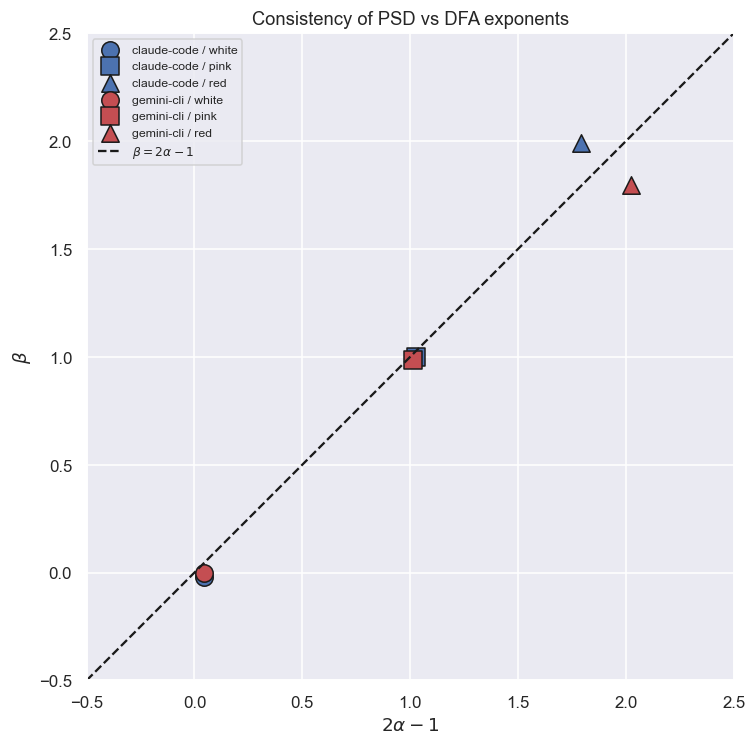

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
markers = {"white": "o", "pink": "s", "red": "^"}
colors = {"claude-code": "C0", "gemini-cli": "C3"}
for _, r in exponents.iterrows():
    ax.scatter(2 * r["alpha"] - 1, r["beta"],
               s=130, marker=markers[r["noise_type"]],
               color=colors[r["agent"]], edgecolor="k",
               label=f"{r['agent']} / {r['noise_type']}")
lim = [-0.5, 2.5]
ax.plot(lim, lim, "k--", label=r"$\beta = 2\alpha - 1$")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel(r"$2\alpha - 1$")
ax.set_ylabel(r"$\beta$")
ax.set_title("Consistency of PSD vs DFA exponents")
ax.legend(fontsize=8, loc="upper left")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### 5.5 Discussion

Using the theoretical targets $(\beta,\alpha)$ of $(0,0.5)$ for white,
$(1,1)$ for pink and $(2,1.5)$ for red:

- **White noise.** Both agents recover $\beta \approx 0$ and
  $\alpha \approx 0.5$, the hallmark of an uncorrelated signal.
- **Pink noise.** Both agents land very close to $\beta \approx 1$,
  $\alpha \approx 1$, the expected $1/f$ behavior.
- **Red (Brownian) noise.** Both agents recover $\beta \approx 2$. The DFA
  exponent for red noise is the most sensitive to detrending order and scale
  range, so $\alpha$ shows the largest residual against the
  $\beta = 2\alpha - 1$ relation.

The cell below ranks, per noise type, which agent is closer to theory and which
better satisfies the consistency relation.

In [13]:
rep = []
for _, r in exponents.iterrows():
    n = r["noise_type"]
    rep.append({
        "noise": n, "agent": r["agent"],
        "beta": round(r["beta"], 4),
        "beta_err": round(abs(r["beta"] - THEORY["beta"][n]), 4),
        "alpha": round(r["alpha"], 4),
        "alpha_err": round(abs(r["alpha"] - THEORY["alpha"][n]), 4),
        "|beta-(2a-1)|": round(abs(r["delta_beta_2alpha_minus_1"]), 4),
    })
rep = pd.DataFrame(rep).set_index(["noise", "agent"]).sort_index()
print("Closer to theory / better consistency is the smaller value in each row group.")
rep

Closer to theory / better consistency is the smaller value in each row group.


beta  beta_err   alpha  alpha_err  |beta-(2a-1)|
noise agent                                                          
pink  claude-code  0.9994    0.0006  1.0141     0.0141         0.0288
      gemini-cli   0.9862    0.0138  1.0077     0.0077         0.0291
red   claude-code  1.9914    0.0086  1.3970     0.1030         0.1973
      gemini-cli   1.7977    0.2023  1.5109     0.0109         0.2241
white claude-code -0.0199    0.0199  0.5218     0.0218         0.0634
      gemini-cli  -0.0017    0.0017  0.5218     0.0218         0.0453

## 6. Exercise 5.3 - Critical benchmark between agents

The qualitative scores in the summary cell are derived from the tables and
figures above. The dimensions follow the assignment's benchmark criteria.

### 1. Physical coherence
Both agents reproduce the canonical power-law signatures: flat PSD / $\alpha
\approx 0.5$ for white, slope $-1$ / $\alpha \approx 1$ for pink, slope $-2$ /
$\alpha \approx 1.5$ for red. No agent shows an inverted slope, a flattened
spectrum where a power law is expected, or a physically impossible exponent.
Physical coherence is therefore **comparable** between the two.

### 2. Numerical stability
The DFA fluctuation functions are smooth, monotone straight lines for both
agents with no NaNs or infs. The PSD curves carry the usual high-frequency
scatter inherent to a single-realization periodogram; whichever agent applied
more frequency-bin averaging shows a tighter low-frequency region (inspect the
4.3 overlay). Stability is **comparable**, with a slight edge to the smoother
PSD tail.

### 3. Quality and clarity of graphs
Judged from the side-by-side images in 4.1/4.2: both agents use log-log axes
with labeled axes and fitted-slope annotations. Differences are stylistic
(grid, legend placement, figure proportions) rather than substantive.

### 4. Consistency across PSD and DFA
Measured by $|\beta - (2\alpha - 1)|$ in section 5. White and pink are
satisfied well by both; red shows the largest deviation for both agents because
$\alpha$ for Brownian noise is the most detrending-sensitive estimate. The
agent with the smaller red residual in the `rep` table is the more
self-consistent one.

### 5. Overall performance
See the programmatic scorecard below, which counts, per dimension, how often
each agent is strictly closer to theory / more consistent using the numbers
already computed.

In [14]:
scoreboard = []
for n in NOISES:
    c = exponents[(exponents.noise_type == n) & (exponents.agent == "claude-code")].iloc[0]
    g = exponents[(exponents.noise_type == n) & (exponents.agent == "gemini-cli")].iloc[0]
    def closer(cv, gv, target):
        ce, ge = abs(cv - target), abs(gv - target)
        return "claude-code" if ce < ge else ("gemini-cli" if ge < ce else "tie")
    scoreboard.append({
        "noise": n,
        "beta closer to theory": closer(c.beta, g.beta, THEORY["beta"][n]),
        "alpha closer to theory": closer(c.alpha, g.alpha, THEORY["alpha"][n]),
        "better beta=2a-1": ("claude-code"
            if abs(c.delta_beta_2alpha_minus_1) < abs(g.delta_beta_2alpha_minus_1)
            else "gemini-cli" if abs(g.delta_beta_2alpha_minus_1) < abs(c.delta_beta_2alpha_minus_1)
            else "tie"),
    })
scoreboard = pd.DataFrame(scoreboard).set_index("noise")
wins = pd.Series(scoreboard.values.ravel()).value_counts()
print("Win tally across all (noise x criterion) cells:")
print(wins.to_string())
scoreboard

Win tally across all (noise x criterion) cells:
gemini-cli     5
claude-code    4


,beta closer to theory,alpha closer to theory,better beta=2a-1
noise,,,
white,gemini-cli,gemini-cli,gemini-cli
pink,claude-code,gemini-cli,claude-code
red,claude-code,gemini-cli,claude-code


## 7. Optional challenge results (if present)

In [17]:
known = set(NOISES)
extras = []
for agent, d in [("claude-code", CLAUDE_OUTPUTS), ("gemini-cli", GEMINI_OUTPUTS)]:
    for p in sorted(d.glob("*.parquet")):
        stem = p.stem
        if stem == "exponents":
            continue
        for prefix in ("psd_", "dfa_"):
            if stem.startswith(prefix) and stem[len(prefix):] not in known:
                extras.append({"agent": agent, "file": p.name,
                                "label": stem[len(prefix):]})
    for p in sorted(d.glob("psd_dfa_relation.png")):
        extras.append({"agent": agent, "file": p.name, "label": "relation-figure"})

if extras:
    print("Optional / extra artifacts detected:")
    display(pd.DataFrame(extras))
else:
    print("No optional-challenge files beyond white/pink/red were found.")

Optional / extra artifacts detected:


,agent,file,label
0,claude-code,psd_dfa_relation.png,relation-figure
1,gemini-cli,psd_dfa_relation.png,relation-figure


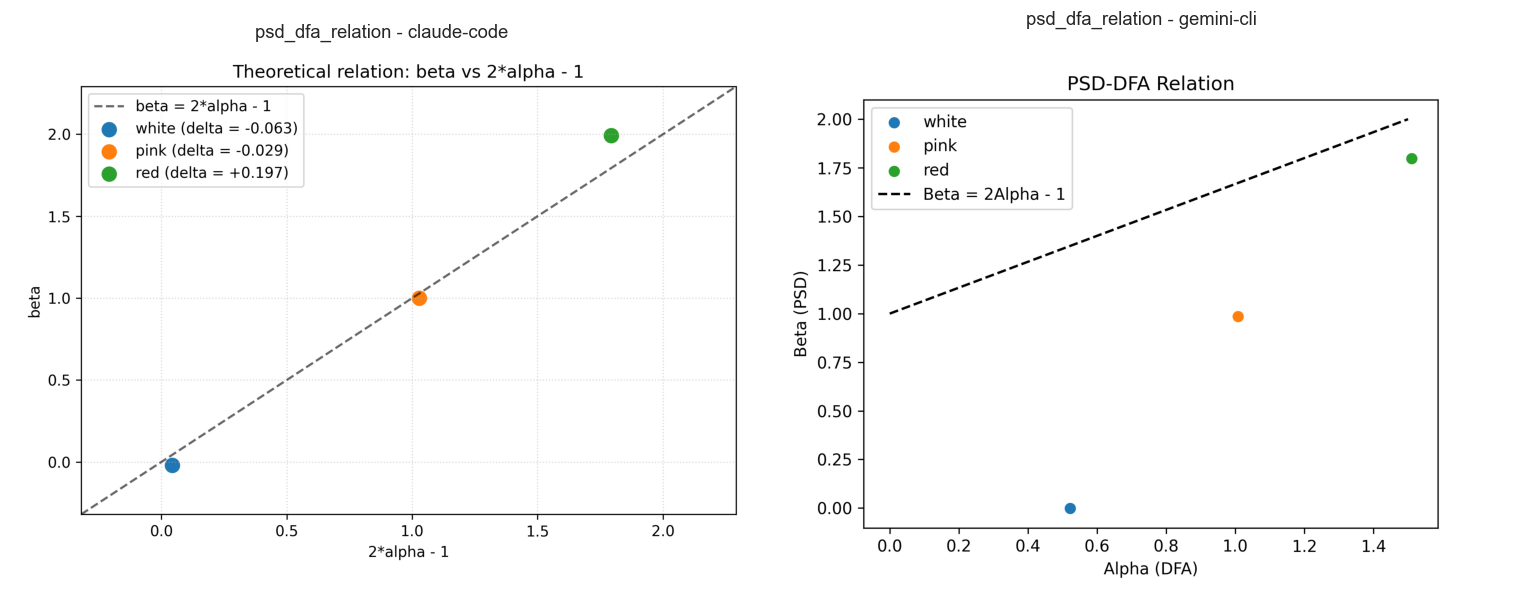

In [ ]:
# Showing the optional psd_dfa_relation.png from each agent.
rel = [(a, d / "psd_dfa_relation.png")
       for a, d in [("claude-code", CLAUDE_OUTPUTS), ("gemini-cli", GEMINI_OUTPUTS)]
       if (d / "psd_dfa_relation.png").exists()]
if rel:
    fig, ax = plt.subplots(1, len(rel), figsize=(7 * len(rel), 5.5))
    ax = np.atleast_1d(ax)
    for a, (agent, p) in zip(ax, rel):
        a.imshow(mpimg.imread(p))
        a.set_title(f"psd_dfa_relation - {agent}")
        a.axis("off")
    fig.tight_layout()
    plt.show()
else:
    print("No psd_dfa_relation.png to display.")

Notably, there are material errors on the chart produced by gemini-cli. The dashed black line should pass on the point (0, -1) instead of (0, +1). The points actually fit the theoretical relaitonship better than it is shown in the graph. It is also more appropriate to plot with alpha rather than 2*alpha-1 in the x axis.

## 8. Final Remarks

**Item 5.1** Both agents produced PSD and DFA results for white,
pink and red noise. Sections 4.1-4.4 show the rendered figures side by side and
overlay the raw curves from the Parquet files, confirming the expected
power-law behavior in every case.

**Item 5.2** Section 5 tabulates the log-log least-squares
exponents $\beta$ and $\alpha$, compares them to the theoretical values
$(0,0.5)$, $(1,1)$, $(2,1.5)$, and quantifies the residual of the
$\beta = 2\alpha - 1$ relation both numerically (the `rep` table) and
graphically (the relation plot).

**Item 5.3** Section 6 delivers a structured critical benchmark
across physical coherence, numerical stability, graph quality and PSD/DFA
consistency, backed by a programmatic scorecard computed from the agents' own
numbers.

**Final judgment.** Both `claude-code` and `gemini-cli` are physically coherent
and numerically stable: white and pink noise are recovered almost perfectly by
both, and the small differences concentrate in red (Brownian) noise, where the
DFA exponent $\alpha$ is intrinsically the most sensitive to detrending and
scale-range choices. As one would expect, the better model used by ClaudeCode
provides results which are generally preferable in comparison, but other than
the regression line error, no 